In [25]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [5]:
Z_train = np.load("../artifacts/data/Z_train.npy")
Z_test  = np.load("../artifacts/data/Z_test.npy")

y_train = np.load("../artifacts/data/y_train.npy")
y_test  = np.load("../artifacts/data/y_test.npy")

print(Z_train.shape, Z_test.shape)


(175341, 64) (82332, 64)


In [6]:
Z_test_t = torch.tensor(Z_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)


In [7]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()


In [8]:
input_dim = Z_test.shape[1]

model = EmbeddingClassifier(input_dim).to(device)
model.load_state_dict(
    torch.load("../artifacts/models/classifier_embeddings_adversarial.pth",
               map_location=device)
)

model.eval()


EmbeddingClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [9]:
start = time.time()

with torch.no_grad():
    logits = model(Z_test_t).squeeze()
    probs  = torch.sigmoid(logits).cpu().numpy()

elapsed = time.time() - start
print(f"Inference time (s): {elapsed:.4f}")


Inference time (s): 0.3393


In [10]:
threshold = 0.73
y_pred = (probs >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

recall = tp / (tp + fn)
fpr    = fp / (fp + tn)
precision = precision_score(y_test, y_pred)
auc = roc_auc_score(y_test, probs)

print(f"Recall (DR) : {recall:.4f}")
print(f"FPR (FAR)   : {fpr:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"ROC AUC    : {auc:.4f}")


Recall (DR) : 0.9113
FPR (FAR)   : 0.0996
Precision  : 0.9181
ROC AUC    : 0.9737


In [11]:
for t in [0.70, 0.73, 0.76]:
    y_p = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_p).ravel()
    r = tp / (tp + fn)
    f = fp / (fp + tn)
    print(f"Threshold {t:.2f} → Recall: {r:.3f} | FPR: {f:.3f}")


Threshold 0.70 → Recall: 0.917 | FPR: 0.110
Threshold 0.73 → Recall: 0.911 | FPR: 0.100
Threshold 0.76 → Recall: 0.905 | FPR: 0.089


In [12]:
def fgsm_attack(x, y, model, eps):
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv).squeeze()
    loss = nn.BCEWithLogitsLoss()(logits, y)
    loss.backward()
    return (x_adv + eps * x_adv.grad.sign()).detach()


In [13]:
eps = 0.02

Z_adv = fgsm_attack(
    Z_test_t,
    y_test_t,
    model,
    eps
)

with torch.no_grad():
    probs_adv = torch.sigmoid(model(Z_adv)).cpu().numpy()

auc_adv = roc_auc_score(y_test, probs_adv)

print(f"ROC AUC (adversarial, eps={eps}): {auc_adv:.4f}")
print(f"AUC drop: {auc - auc_adv:.4f}")


ROC AUC (adversarial, eps=0.02): 0.9067
AUC drop: 0.0670


In [14]:
y_adv_pred = (probs_adv >= threshold).astype(int)
asr = np.mean(y_adv_pred != y_test)

print(f"Attack Success Rate (ASR): {asr:.4f}")


Attack Success Rate (ASR): 0.1414


In [15]:
auc_before = 0.9745  # ajuste com seu valor real
forgetting = auc_before - auc

print(f"Forgetting rate: {forgetting:.4f}")


Forgetting rate: 0.0008


In [16]:
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params}")


Total parameters: 4225


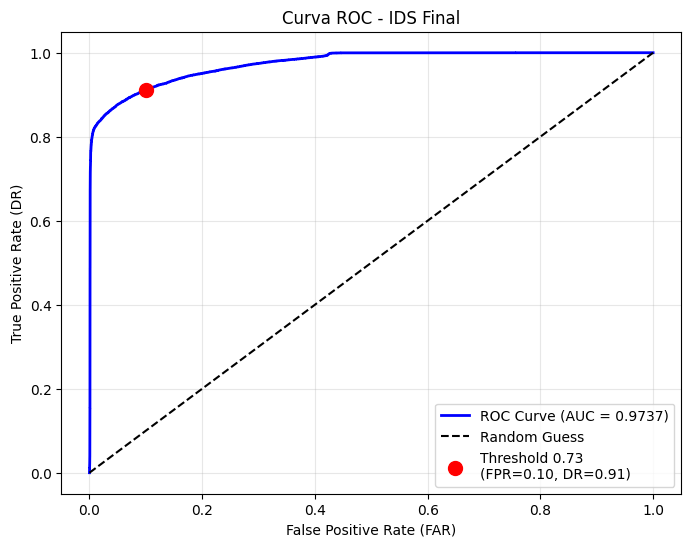

In [17]:
fpr_list, tpr_list, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, label=f'ROC Curve (AUC = {auc:.4f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Marcar o seu threshold de 0.73 no gráfico
plt.scatter(fpr, recall, color='red', s=100, label=f'Threshold 0.73\n(FPR={fpr:.2f}, DR={recall:.2f})', zorder=5)

plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (DR)')
plt.title('Curva ROC - IDS Final')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

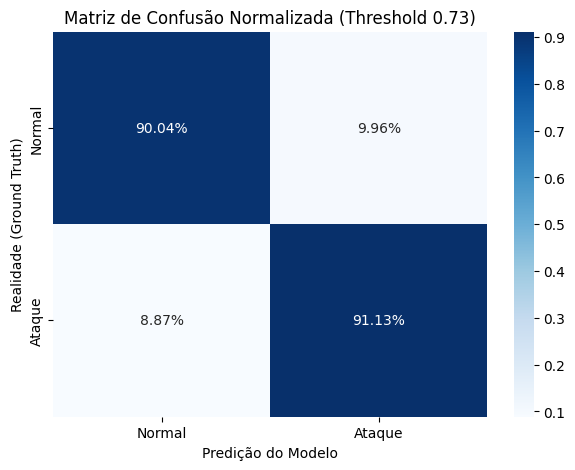

In [18]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalização

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Normal', 'Ataque'], 
            yticklabels=['Normal', 'Ataque'])
plt.xlabel('Predição do Modelo')
plt.ylabel('Realidade (Ground Truth)')
plt.title('Matriz de Confusão Normalizada (Threshold 0.73)')
plt.show()

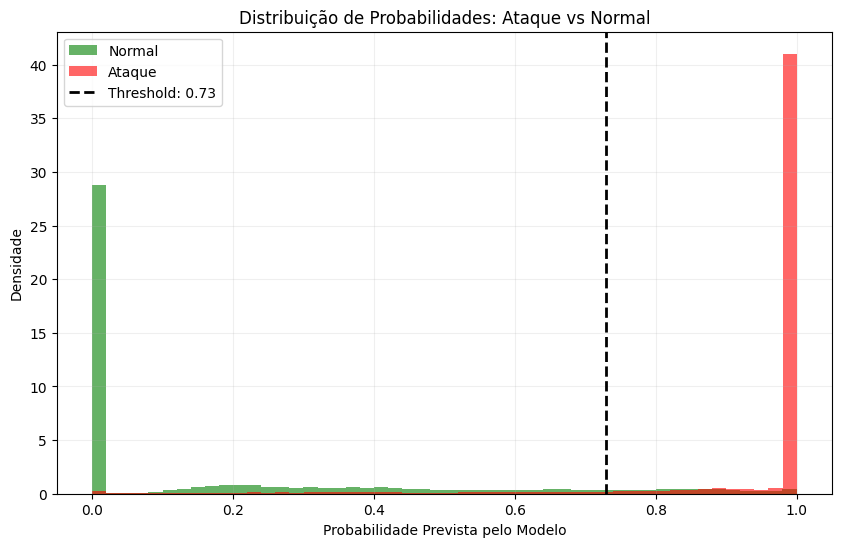

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(probs[y_test == 0], bins=50, alpha=0.6, label='Normal', color='green', density=True)
plt.hist(probs[y_test == 1], bins=50, alpha=0.6, label='Ataque', color='red', density=True)

# Linha do Threshold
plt.axvline(threshold, color='black', linestyle='--', lw=2, label=f'Threshold: {threshold}')

plt.xlabel('Probabilidade Prevista pelo Modelo')
plt.ylabel('Densidade')
plt.title('Distribuição de Probabilidades: Ataque vs Normal')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

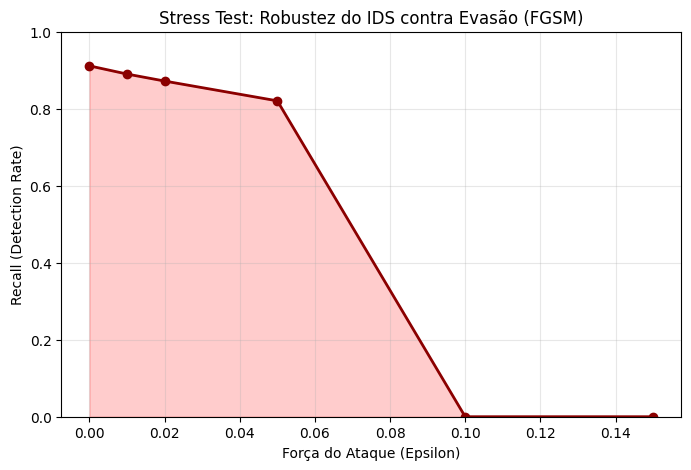

In [20]:
epsilons = [0, 0.01, 0.02, 0.05, 0.1, 0.15]
recalls = []

model.eval()
for eps in epsilons:
    if eps == 0:
        Z_adv = Z_test_t
    else:
        # Usando sua função fgsm_attack já definida
        Z_adv = fgsm_attack(Z_test_t, y_test_t, model, eps)
    
    with torch.no_grad():
        p_adv = torch.sigmoid(model(Z_adv)).cpu().numpy()
        y_p_adv = (p_adv >= 0.73).astype(int)
        recalls.append(recall_score(y_test, y_p_adv))

plt.figure(figsize=(8, 5))
plt.plot(epsilons, recalls, marker='o', linestyle='-', color='darkred', linewidth=2)
plt.fill_between(epsilons, recalls, alpha=0.2, color='red')
plt.xlabel('Força do Ataque (Epsilon)')
plt.ylabel('Recall (Detection Rate)')
plt.title('Stress Test: Robustez do IDS contra Evasão (FGSM)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

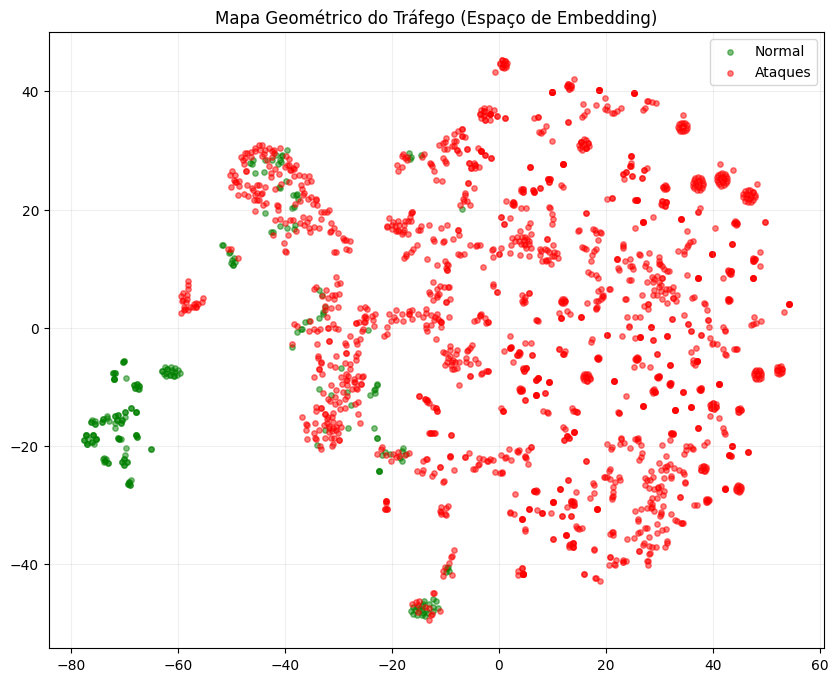

In [23]:
# 1. Reduzir para 2D para visualização
tsne = TSNE(n_components=2, random_state=42)
Z_2d = tsne.fit_transform(Z_test[:2000]) # Usando amostra para velocidade
y_sample = y_test[:2000]

plt.figure(figsize=(10, 8))
# Pontos Normais
plt.scatter(Z_2d[y_sample == 0, 0], Z_2d[y_sample == 0, 1], 
            c='green', label='Normal', alpha=0.5, s=15)
# Ataques Conhecidos
plt.scatter(Z_2d[y_sample == 1, 0], Z_2d[y_sample == 1, 1], 
            c='red', label='Ataques', alpha=0.5, s=15)

plt.title("Mapa Geométrico do Tráfego (Espaço de Embedding)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

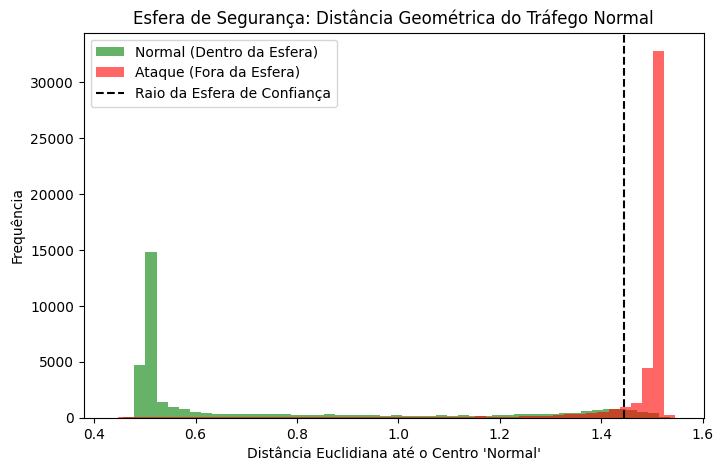

In [24]:
centers = np.mean(Z_test[y_test == 0], axis=0) # Centro do tráfego normal
distances = np.linalg.norm(Z_test - centers, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(distances[y_test == 0], bins=50, alpha=0.6, color='green', label='Normal (Dentro da Esfera)')
plt.hist(distances[y_test == 1], bins=50, alpha=0.6, color='red', label='Ataque (Fora da Esfera)')
plt.axvline(np.percentile(distances[y_test == 0], 95), color='black', linestyle='--', label='Raio da Esfera de Confiança')

plt.title("Esfera de Segurança: Distância Geométrica do Tráfego Normal")
plt.xlabel("Distância Euclidiana até o Centro 'Normal'")
plt.ylabel("Frequência")
plt.legend()
plt.show()

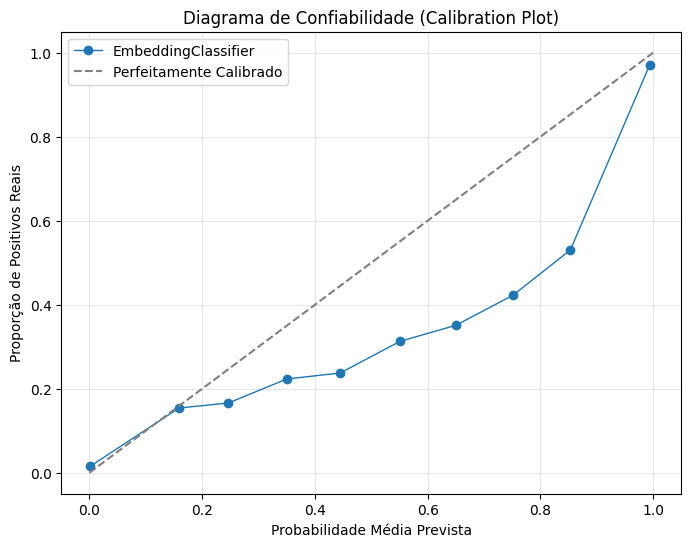

In [26]:
# Cálculo da curva de calibração
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='EmbeddingClassifier')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeitamente Calibrado')

plt.xlabel('Probabilidade Média Prevista')
plt.ylabel('Proporção de Positivos Reais')
plt.title('Diagrama de Confiabilidade (Calibration Plot)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
def calculate_class_separation(Z, y):
    # Separa os embeddings por classe
    z_normal = Z[y == 0]
    z_ataque = Z[y == 1]
    
    # Calcula os centroides (médias) no espaço 64D
    mu_normal = np.mean(z_normal, axis=0)
    mu_ataque = np.mean(z_ataque, axis=0)
    
    # Distância Euclidiana entre os centros
    distance = np.linalg.norm(mu_normal - mu_ataque)
    
    # Dispersão interna (Intra-class variance)
    std_normal = np.std(np.linalg.norm(z_normal - mu_normal, axis=1))
    
    return distance, std_normal

dist, std = calculate_class_separation(Z_test, y_test)
print(f"Distância entre centros de classe: {dist:.4f}")
print(f"Dispersão (Variância) da classe Normal: {std:.4f}")

Distância entre centros de classe: 1.4086
Dispersão (Variância) da classe Normal: 0.3465


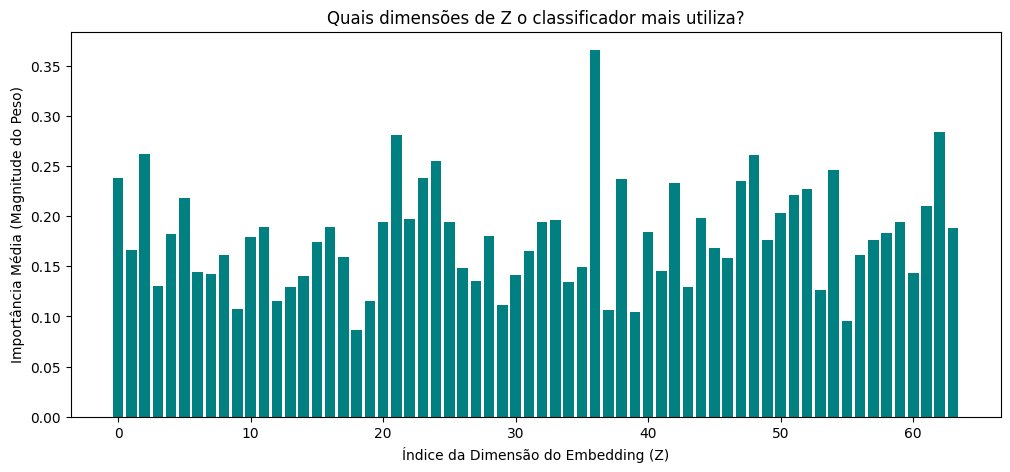

In [28]:
# Extração de pesos da primeira camada do classificador
weights = model.net[0].weight.abs().detach().cpu().numpy()
importance_z = np.mean(weights, axis=0)

plt.figure(figsize=(12, 5))
plt.bar(range(len(importance_z)), importance_z, color='teal')
plt.xlabel('Índice da Dimensão do Embedding (Z)')
plt.ylabel('Importância Média (Magnitude do Peso)')
plt.title('Quais dimensões de Z o classificador mais utiliza?')
plt.show()

In [29]:
# Encontrar casos onde o modelo errou feio (Falsos Negativos Críticos)
# Ataques reais (y=1) onde a probabilidade foi muito baixa
hard_fn_idx = np.where((y_test == 1) & (probs < 0.2))[0]

# Tráfego normal (y=0) onde a probabilidade foi muito alta (Falsos Positivos)
hard_fp_idx = np.where((y_test == 0) & (probs > 0.8))[0]

print(f"Quantidade de Falsos Negativos Críticos: {len(hard_fn_idx)}")
print(f"Quantidade de Falsos Positivos Críticos: {len(hard_fp_idx)}")

# Exemplo: Extrair os embeddings desses erros para análise posterior
Z_hard_samples = Z_test[hard_fn_idx]

Quantidade de Falsos Negativos Críticos: 744
Quantidade de Falsos Positivos Críticos: 2745
